In [1]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from pynamicalsys import DiscreteDynamicalSystem as dds

In [2]:
k = 1.5
x = 0.5
ny = 1000
y = np.linspace(0, 1, ny)
total_time = int(1e4)
ds = dds(model="standard map")
ds.set_parameters(k)

In [3]:
total_time, type(total_time)

(10000, int)

In [4]:
dig = Parallel(n_jobs=-1)(delayed(ds.dig)(np.array([x, y[i]]), total_time) for i in range(ny))
dig = np.array(dig)

/Users/mrolims/Library/Mobile Documents/com~apple~CloudDocs/Research/Projects/pynamicalsys/src/pynamicalsys/discrete_time/birkhoff.py:120: RuntimeWarning: divide by zero encountered in log10
  return float(-np.log10(abs(wb0 - wb1)))
/Users/mrolims/Library/Mobile Documents/com~apple~CloudDocs/Research/Projects/pynamicalsys/src/pynamicalsys/discrete_time/birkhoff.py:120: RuntimeWarning: divide by zero encountered in log10
  return float(-np.log10(abs(wb0 - wb1)))
/Users/mrolims/Library/Mobile Documents/com~apple~CloudDocs/Research/Projects/pynamicalsys/src/pynamicalsys/discrete_time/birkhoff.py:120: RuntimeWarning: divide by zero encountered in log10
  return float(-np.log10(abs(wb0 - wb1)))
/Users/mrolims/Library/Mobile Documents/com~apple~CloudDocs/Research/Projects/pynamicalsys/src/pynamicalsys/discrete_time/birkhoff.py:120: RuntimeWarning: divide by zero encountered in log10
  return float(-np.log10(abs(wb0 - wb1)))
/Users/mrolims/Library/Mobile Documents/com~apple~CloudDocs/Research

In [5]:
lypnv = Parallel(n_jobs=-1)(delayed(ds.lyapunov)(np.array([x, y[i]]), total_time) for i in range(ny))
lypnv = np.array(lypnv)

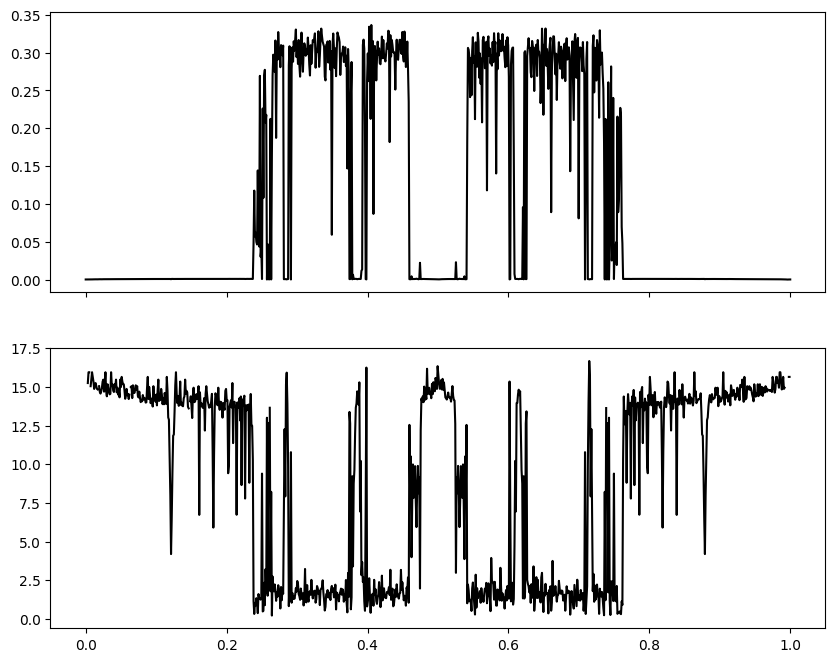

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax[0].plot(y, lypnv[:, 0], "k")
ax[1].plot(y, dig, "k")